Diffusers and pipeline Code

In [1]:
from diffusers import StableDiffusion3Pipeline
import torch
from config import LAM_VALUES, TSR_DIR, PT_TSR_DIR, PROMPTS_FILE, MODEL_CACHE, SEED, TSR_SIGMA, SWAP_ALGORITHM, N_INF_STEPS, GUIDANCE_SCALE

    # ── Load model once ───────────────────────────────────────────────────────────
pipe = StableDiffusion3Pipeline.from_pretrained(
	"stabilityai/stable-diffusion-3-medium-diffusers",
	torch_dtype=torch.float16,
	cache_dir=MODEL_CACHE,
)
pipe = pipe.to("cuda")
pipe.set_progress_bar_config(disable=True)

Loading pipeline components...:   0%|          | 0/9 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

Imports, configs

In [ ]:
from pathlib import Path
import gc
import pandas as pd
from tqdm import tqdm
import shutil

TSR_DIR     = Path("/n/netscratch/kempner_undergrads/Everyone/zwu/parallel_toy/images/tsr_samples_tester_new")
PT_TSR_DIR  = Path("/n/netscratch/kempner_undergrads/Everyone/zwu/parallel_toy/images/pt_samples_tester_new")

REPLICA_EXCHANGE = True
LAM_VALUES = [1.2]
INDEX_UNTIL = 6

gc.collect()
torch.cuda.empty_cache()

SWAP_ALGORITHM = {
	"n_replicas": 3,
	"p_ratio": "p",
	"even_indices": [0, 6, 9],
	"odd_indices":  [2, 7, 10],
	"debug": True,
}
    

In [ ]:
if PT_TSR_DIR.exists():
    shutil.rmtree(PT_TSR_DIR)

Sample!

In [3]:
# ── Load prompts once ─────────────────────────────────────────────────────────
prompts = pd.read_csv(PROMPTS_FILE, usecols=["text"], nrows=INDEX_UNTIL)["text"].tolist()
print(f"Loaded {len(prompts)} prompts")


replica_exchanges = [False, True]

lam_dirs = {}
for re in replica_exchanges:
	base = PT_TSR_DIR if re else TSR_DIR
	lam_dirs[re] = {l: base / f"lam{l:.3f}".replace(".", "p") for l in LAM_VALUES}
	for d in lam_dirs[re].values():
		d.mkdir(parents=True, exist_ok=True)

# ── Sweep ─────────────────────────────────────────────────────────────────────
for idx, prompt in enumerate(prompts):
	
	for replica_exchange in replica_exchanges:
	
		for tsr_lam in tqdm(LAM_VALUES, desc=f"idx={idx} re={replica_exchange}"):

			output_dir = lam_dirs[replica_exchange][tsr_lam]

			if (output_dir / f"{idx:05d}.png").exists():
				continue

			generator = torch.Generator(device="cuda").manual_seed(SEED)

			images = pipe(
				prompt,
				negative_prompt="",
				num_inference_steps=N_INF_STEPS,
				guidance_scale=GUIDANCE_SCALE,
				tsr_lam=tsr_lam,
				tsr_sigma=TSR_SIGMA,
				replica_exchange=replica_exchange,
				swap_algorithm=SWAP_ALGORITHM,
				generator=generator,
			).images

			out_path = output_dir / f"{idx:05d}.png"
			images[0].save(out_path, icc_profile=None)


			del images
		torch.cuda.empty_cache()

print("\n All k values complete.")

Loaded 6 prompts


idx=0 re=True:   0%|          | 0/1 [00:00<?, ?it/s]

 We tsr by 1.20 with replica exchange True
Time 1000.00 swap btwn source 1.33 and target 1.20 accept 1.000 std 0.984
Time 975.98 swap btwn source 1.48 and target 1.33 accept 1.000 std 0.959
Time 920.28 swap btwn source 1.33 and target 1.20 accept 0.999 std 0.912
Time 904.45 swap btwn source 1.48 and target 1.33 accept 0.997 std 0.901
Time 870.06 swap btwn source 1.33 and target 1.20 accept 0.995 std 0.881
Time 851.33 swap btwn source 1.48 and target 1.33 accept 0.994 std 0.872


idx=1 re=True:   0%|          | 0/1 [00:00<?, ?it/s]

 We tsr by 1.20 with replica exchange True
Time 1000.00 swap btwn source 1.33 and target 1.20 accept 1.000 std 0.985
Time 975.98 swap btwn source 1.48 and target 1.33 accept 1.000 std 0.959
Time 920.28 swap btwn source 1.33 and target 1.20 accept 0.999 std 0.910
Time 904.45 swap btwn source 1.48 and target 1.33 accept 0.998 std 0.898
Time 870.06 swap btwn source 1.33 and target 1.20 accept 0.995 std 0.875
Time 851.33 swap btwn source 1.48 and target 1.33 accept 0.994 std 0.864


...

 We tsr by 1.20 with replica exchange True
Time 1000.00 swap btwn source 1.33 and target 1.20 accept 1.000 std 0.984
Time 975.98 swap btwn source 1.48 and target 1.33 accept 1.000 std 0.958
Time 920.28 swap btwn source 1.33 and target 1.20 accept 0.999 std 0.905
Time 904.45 swap btwn source 1.48 and target 1.33 accept 0.998 std 0.892
Time 870.06 swap btwn source 1.33 and target 1.20 accept 0.997 std 0.864
Time 851.33 swap btwn source 1.48 and target 1.33 accept 0.996 std 0.851


idx=5 re=True:   0%|          | 0/1 [00:00<?, ?it/s]

 We tsr by 1.20 with replica exchange True
Time 1000.00 swap btwn source 1.33 and target 1.20 accept 1.000 std 0.984
Time 975.98 swap btwn source 1.48 and target 1.33 accept 1.000 std 0.958
Time 920.28 swap btwn source 1.33 and target 1.20 accept 0.999 std 0.906
Time 904.45 swap btwn source 1.48 and target 1.33 accept 0.998 std 0.893
Time 870.06 swap btwn source 1.33 and target 1.20 accept 0.996 std 0.865
Time 851.33 swap btwn source 1.48 and target 1.33 accept 0.995 std 0.852


idx=5 re=True: 100%|██████████| 1/1 [00:32<00:00, 32.88s/it]


 All k values complete.


Fid computation

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

/n/home00/zoewu/.local/lib/python3.12/site-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Computing real image features...


100%|██████████| 1/1 [00:01<00:00,  1.77s/it]


Real features computed from 70 images.


── lam1p200 ──


CLIP lam=1.2: 100%|██████████| 6/6 [00:00<00:00, 18.53it/s]


[True]  lam=1.200  FID=346.1340  CLIP=31.7276


CLIP lam=1.2: 100%|██████████| 6/6 [00:00<00:00, 17.73it/s]


[False]  lam=1.200  FID=346.2207  CLIP=31.8183


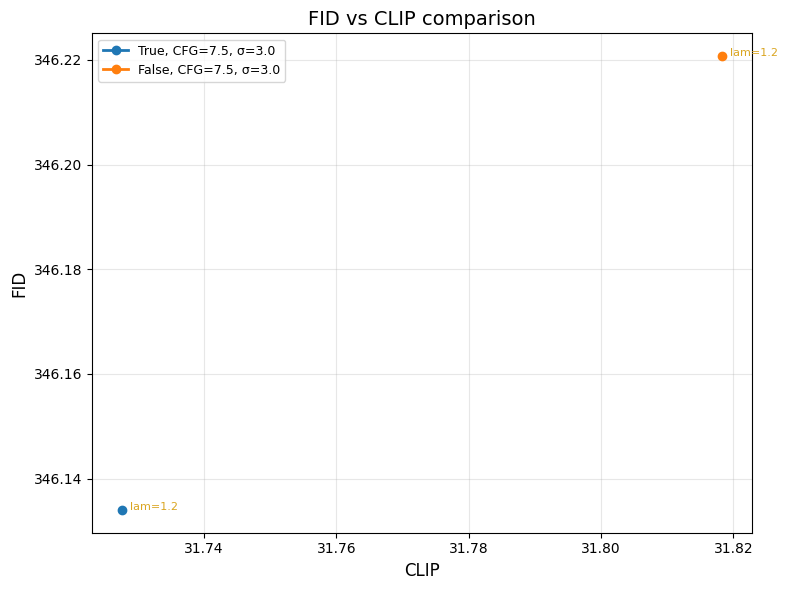

{True: {1.2: (np.float64(346.1340070050436), np.float64(31.727578163146973))},
 False: {1.2: (np.float64(346.2207446848582), np.float64(31.818265914916992))}}

In [4]:
from fid import compute_sweep

compute_sweep(
	lam_values=[ 1.2],
	replica_exchanges=[True, False],
	device="cuda",
	target_indices=None,
	index_until = 70,
	pt_sr_dir = PT_TSR_DIR,
	tsr_dir = TSR_DIR,
)